This notebook is used for Data Acquisition from a Keithley 6485 Picoammeter to measure the efficiency of ions  traveling through the system to the detector. This is done by measuring the current on Picoammeter (ions hitting the aperature) and seeing the ion count rate on the detector.

MiniMagneTOF Efficiency 80%

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob 

In [62]:
def read_mpa_file(filepath):
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum


# Naming Scheme: Current{amps}_{run}.mpa
# Need to place "." after first integer in {amps} to get the correct float value for amps
def get_amps(filename, prefix):
    name_only = filename.replace(prefix, "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only) / 1000

def get_run(filename):
    name_only = filename.replace("Current", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1

data_folder = "EfficiencyControl"
rows = []

def build_df(data_folder, glob_pattern, prefix, exclude=None):
    rows = []
    for filepath in glob.glob(os.path.join(data_folder, glob_pattern)):
        filename = os.path.basename(filepath)
        if exclude and exclude in filename:
            continue  # skip files that belong to the other set

        amps = get_amps(filename, prefix)
        realtime, totalsum = read_mpa_file(filepath)
        rate = totalsum / realtime
        run = get_run(filename)

        rows.append({
            "amps": amps,
            "file": filename,
            "run": run,
            "realtime_s": realtime,
            "totalsum": totalsum,
            "rate_hz": rate
        })
    return pd.DataFrame(rows)

efficiency_df = build_df(data_folder, "Efficiency*.mpa", "Efficiency", exclude="Noise")
efficiency_df = efficiency_df.sort_values(by=["amps", "run"]).reset_index(drop=True)
efficiency_df['rate_err'] = np.sqrt(efficiency_df['totalsum']) / efficiency_df['realtime_s']  # Poisson error propagation

# Read in Noise tests (Dark Counts + TDC Noise, taken without Heat Source)
# efficiency_noise_df = build_df(data_folder, "EfficiencyNoise*.mpa", "EfficiencyNoise")
# efficiency_noise_df = efficiency_noise_df.sort_values(by=["amps"]).reset_index(drop=True)
efficiency_single = efficiency_df[efficiency_df['run'] == 1].copy()
efficiency_df

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err
0,0.750,Efficiency0750.mpa,1,150.136,9.0,0.059946,0.019982
1,0.800,Efficiency0800.mpa,1,150.101,59.0,0.393069,0.051173
2,0.850,Efficiency0850.mpa,1,150.293,678.0,4.511188,0.173251
3,0.900,Efficiency0900.mpa,1,150.295,9864.0,65.630926,0.660818
4,0.900,Efficiency0900_2.mpa,2,150.117,23.0,0.153214,0.031947
5,0.925,Efficiency0925_2.mpa,2,150.116,65.0,0.432998,0.053707
6,0.950,Efficiency0950.mpa,1,150.101,102486.0,682.780261,2.132793
7,0.950,Efficiency0950_2.mpa,2,150.061,163.0,1.086225,0.085080
8,0.975,Efficiency0975.mpa,1,150.099,371810.0,2477.098448,4.062400
9,0.975,Efficiency0975_2.mpa,2,150.367,490.0,3.258694,0.147213


In [63]:
run1 = efficiency_df[efficiency_df['run'] == 1].copy()

# Pressure Gauge: ~3.7e-7, Detector Bias: -2000V, Threshold: -7mV (07/01/26)
# 15 Minute wait between each current step to allow for stabilization of the system.

current = [0.749, 0.799, 0.849, 0.900, 0.950, 0.975, 0.998, 1.024, 1.049] # A
voltage = [1.22, 1.36, 1.49, 1.63, 1.77, 1.86, 1.92, 2.00, 2.08] # V


# Picoammeter readings at each current step (pA) 
amp_current0750 = [0.09,0.03,0.12,0.17,0.11,0.42,0.06,0.02,0.16,0.13] 
amp_current0800 = [0.09,0.04,0.14,0.02,0.12,0.15,0.13,0.04,0.26,0.10]
amp_current8500 = [0.21,0.12,0.09,0.15,0.18,0.11,0.14,0.36,0.13,0.16]
amp_current0900 = [0.07,0.03,0.16,0.31,0.12,0.09,0.05,0.25,0.04,0.01]
amp_current0950 = [0.95,0.38,0.19,0.02,0.27,0.13,0.20,0.12,0.18,0.42] 
amp_current0975 = [1.36,1.55,1.74,1.40,1.10,1.29,1.18,1.09,1.43,1.54]
amp_current1000 = [3.72,2.53,3.76,3.92,4.09,3.69,3.52,3.74,3.78,3.87]
amp_current1025 = [10.35,10.03,11.57,10.19,10.24,10.51,10.23,10.32,9.65,10.20]
amp_current1050 = [23.89,24.10,24.11,24.25,24.32,24.27,24.60,24.42,24.27,24.05]
amp_lists = [amp_current0750, amp_current0800, amp_current8500, amp_current0900, amp_current0950, amp_current0975, amp_current1000, amp_current1025, amp_current1050]

avg_ap_current = []
avg_ap_unc = []
ap_ion_rate = []
ap_ion_rate_unc = []

for amps, amp_current in zip(run1['amps'], amp_lists):
    n = len(amp_current)
    avg_current = np.mean(amp_current) # Gets the mean of the current readings for this step (pA)
    avg_current_unc = np.std(amp_current, ddof=1) / np.sqrt(n) # Calculates the standard error of the mean (SEM) for the current readings

    avg_ap_current.append(avg_current) 
    avg_ap_unc.append(avg_current_unc)

    ion_rate = avg_current * 1e-12 / 1.602e-19 # Calculates the ion rate in Hz using the average current (pA) and the elementary charge (C)
    ion_rate_unc = avg_current_unc * 1e-12 / 1.602e-19 # Calculates the uncertainty in the ion rate using the uncertainty in the average current (pA) and the elementary charge (C)
    ap_ion_rate.append(ion_rate)
    ap_ion_rate_unc.append(ion_rate_unc)

run1['ap_current_pA'] = avg_ap_current
run1['ap_current_unc_pA'] = avg_ap_unc
run1['ap_rate'] = ap_ion_rate
run1['ap_rate_err'] = ap_ion_rate_unc
run1['ratio'] = run1['rate_hz'] / run1['ap_rate']
run1['ratio_err'] = np.sqrt((run1['rate_err'] / run1['ap_rate'])**2 + (run1['rate_hz'] * run1['ap_rate_err'] / run1['ap_rate_err']**2)**2)
run1

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err,ap_current_pA,ap_current_unc_pA,ap_rate,ap_rate_err,ratio,ratio_err
0,0.750,Efficiency0750.mpa,1,150.136,9.0,0.059946,0.019982,0.131,0.035853,8.177278e+05,223802.093170,7.330758e-08,2.689635e-07
1,0.800,Efficiency0800.mpa,1,150.101,59.0,0.393069,0.051173,0.109,0.022083,6.803995e+05,137847.541199,5.777028e-07,2.852466e-06
2,0.850,Efficiency0850.mpa,1,150.293,678.0,4.511188,0.173251,0.165,0.024278,1.029963e+06,151551.042319,4.379954e-06,2.976727e-05
3,0.900,Efficiency0900.mpa,1,150.295,9864.0,65.630926,0.660818,0.113,0.031448,7.053683e+05,196306.931255,9.304491e-05,3.343294e-04
6,0.950,Efficiency0950.mpa,1,150.101,102486.0,682.780261,2.132793,0.286,0.082895,1.785268e+06,517445.982367,3.824524e-04,1.319520e-03
8,0.975,Efficiency0975.mpa,1,150.099,371810.0,2477.098448,4.062400,1.368,0.066379,8.539326e+06,414353.189776,2.900813e-04,5.978229e-03
10,1.000,Efficiency1000.mpa,1,150.009,809248.0,5394.662987,5.996854,3.662,0.134510,2.285893e+07,839636.764283,2.359981e-04,6.424996e-03
12,1.025,Efficiency1025.mpa,1,150.062,1879242.0,12523.103784,9.135254,10.329,0.155545,6.447566e+07,970944.303609,1.942300e-04,1.289786e-02
14,1.050,Efficiency1050.mpa,1,150.015,4015426.0,26766.829984,13.357683,24.228,0.063592,1.512360e+08,396956.631600,1.769872e-04,6.743011e-02


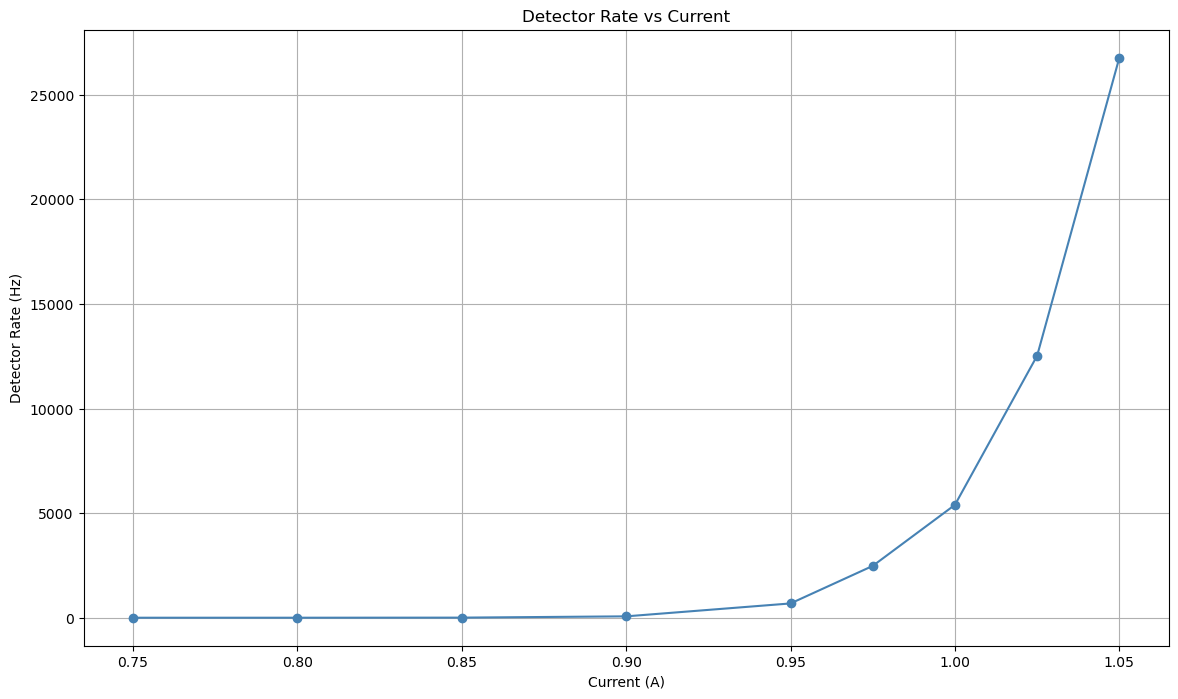

In [64]:
plt.figure(figsize=(14, 8))
plt.plot(run1['amps'], run1['rate_hz'], marker='o', label='Detector Rate', color='steelblue')
plt.xlabel('Current (A)')
plt.ylabel('Detector Rate (Hz)')
plt.title('Detector Rate vs Current')
plt.grid()
plt.show()

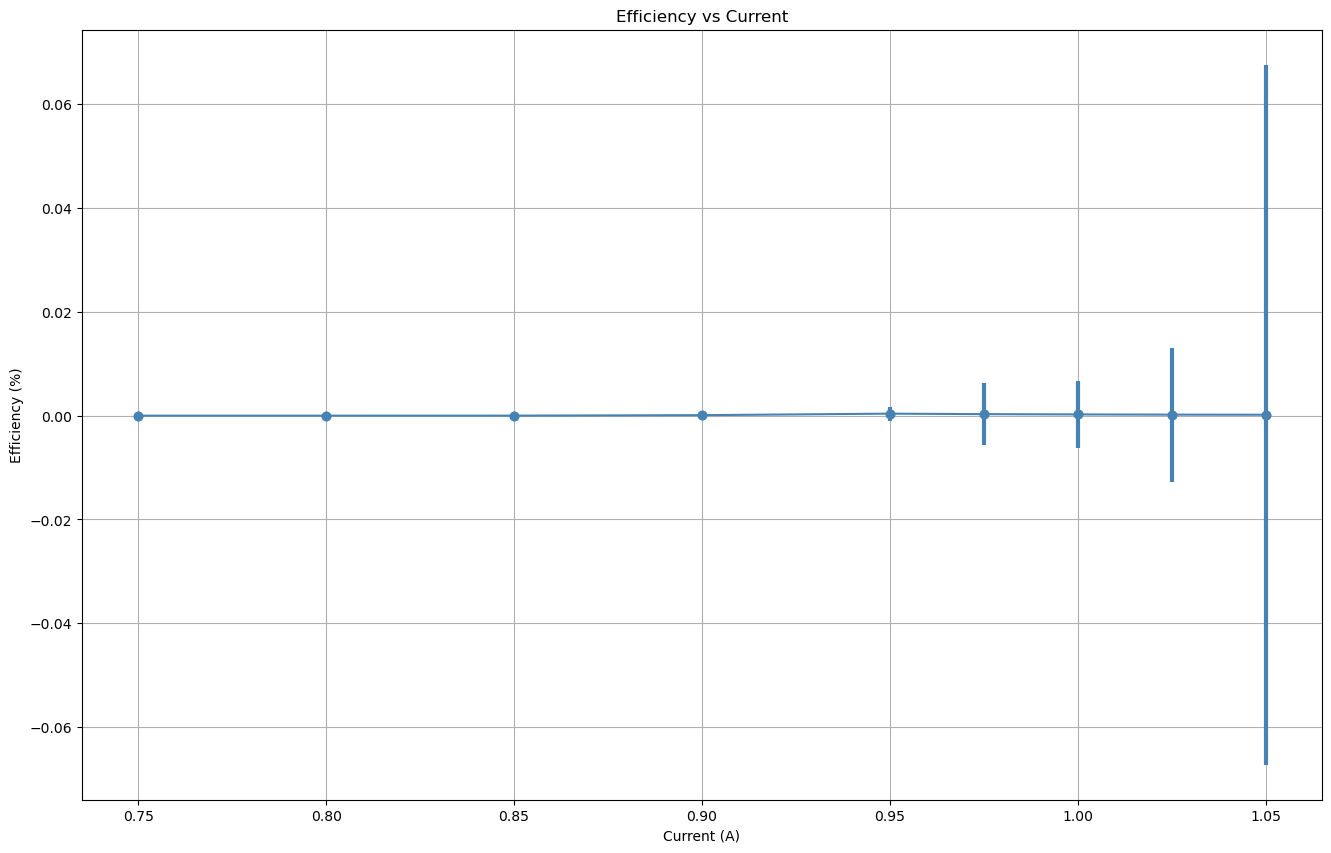

In [65]:
plt.figure(figsize=(16, 10))
plt.plot(run1['amps'], run1['ratio'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(run1['amps'], run1['ratio'], yerr=run1['ratio_err'], fmt='o', color='steelblue', ecolor='steelblue', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('Efficiency (%)')
plt.title('Efficiency vs Current')
plt.grid()
plt.show()

# Single Amp Measurement

In [66]:
amp_current = [0.12, 0.04, 0.15, 0.31, 0.13, 1.29, 3.69, 10.24, 24.32] #pA

ion_rates = []
for amp in amp_current:
    ion_rate = amp * 1e-12 / 1.602e-19 # Calculates the ion rate in Hz using the average current (pA) and the elementary charge (C)
    ion_rates.append(ion_rate)

efficiency_single['ap_rate'] = ion_rates
efficiency_single['ratio'] = efficiency_single['rate_hz'] / efficiency_single['ap_rate']


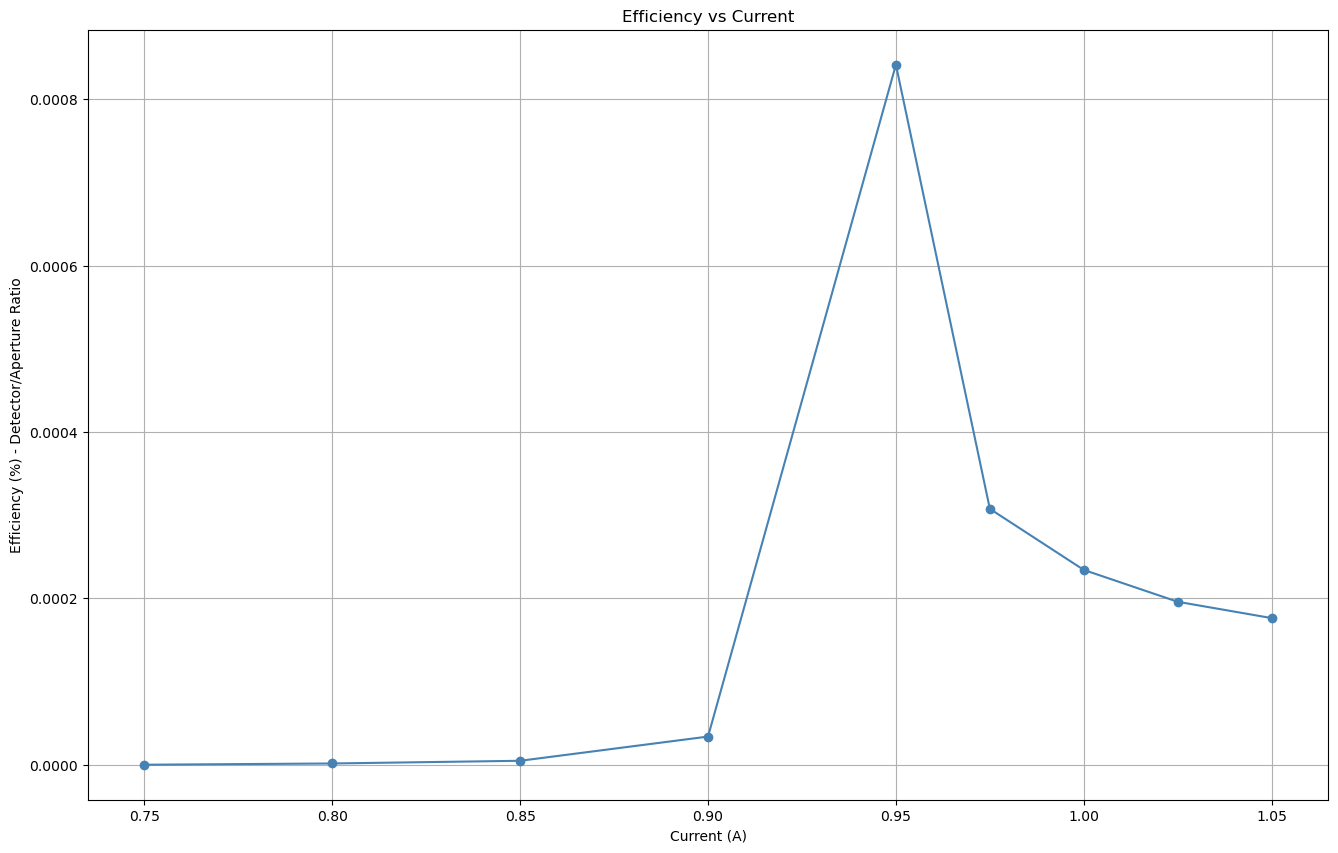

In [67]:
plt.figure(figsize=(16, 10))
plt.plot(efficiency_single['amps'], efficiency_single['ratio'], marker='o', label='Detector Rate', color='steelblue')
plt.xlabel('Current (A)')
plt.ylabel('Efficiency (%) - Detector/Aperture Ratio')
plt.title('Efficiency vs Current')
plt.grid()
plt.show()

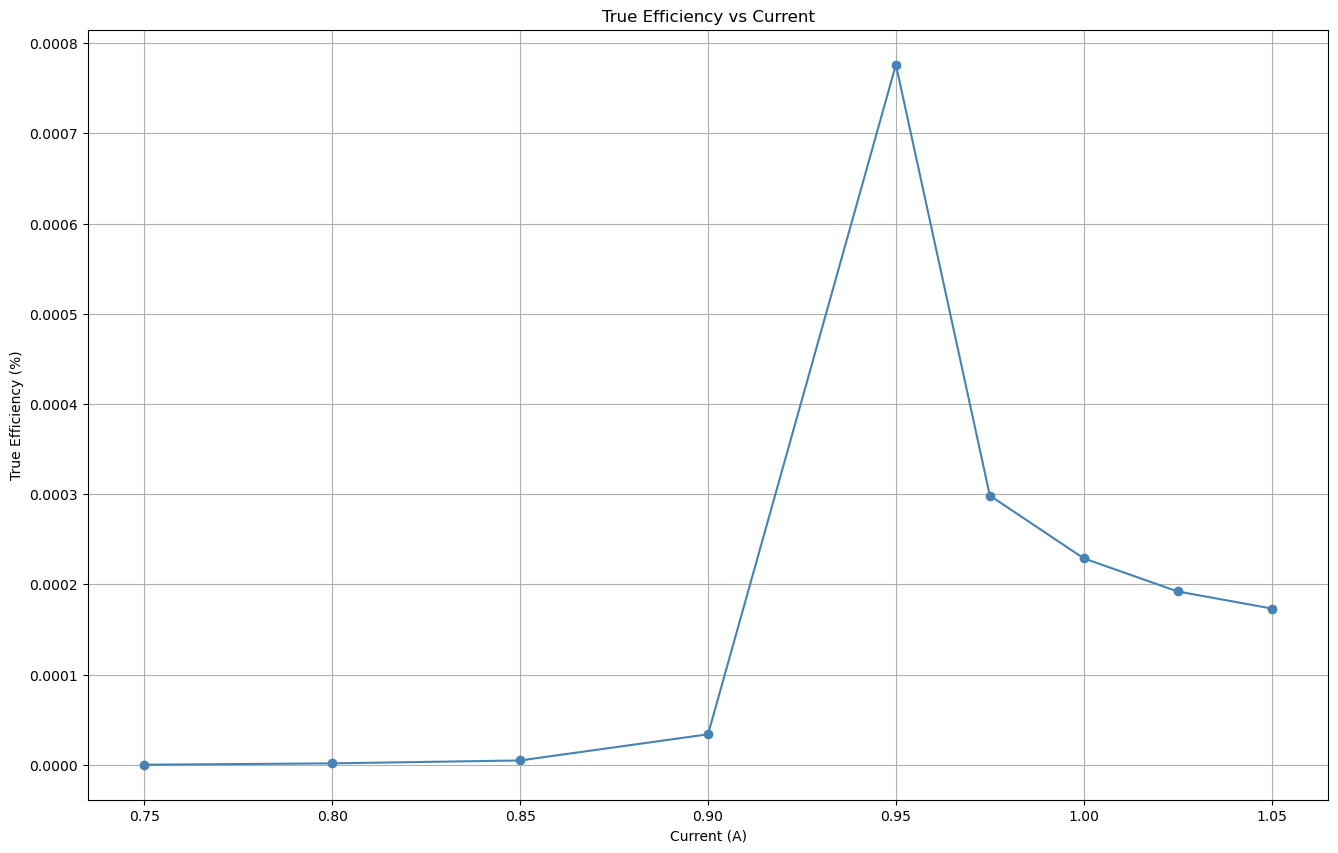

In [68]:
efficiency_single['efficiency'] = efficiency_single['rate_hz']/(efficiency_single['ap_rate'] + efficiency_single['rate_hz'] * 100)

plt.figure(figsize=(16, 10))
plt.plot(efficiency_single['amps'], efficiency_single['efficiency'], marker='o', label='Detector Rate', color='steelblue')
plt.xlabel('Current (A)')
plt.ylabel('True Efficiency (%)')
plt.title('True Efficiency vs Current')
plt.grid()
plt.show()

# Run 2 - Taken at a Lower 1800V Detector Bias

[]

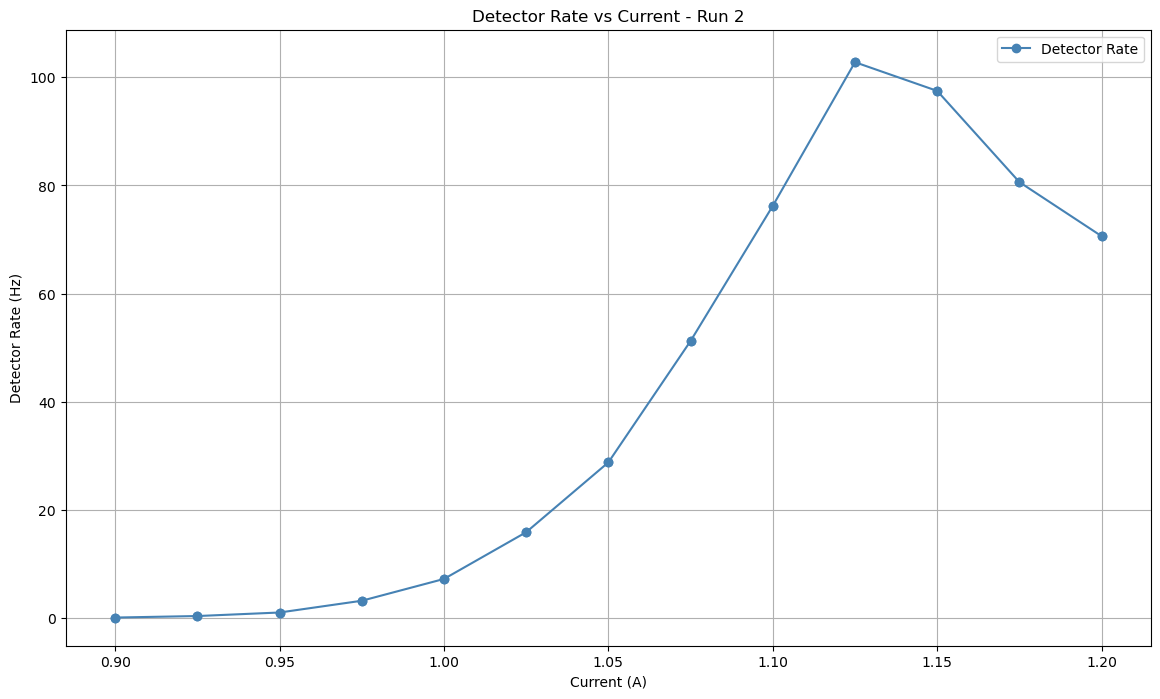

In [69]:
run2 = efficiency_df[efficiency_df['run'] == 2]

plt.figure(figsize=(14, 8))
plt.plot(run2['amps'], run2['rate_hz'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(run2['amps'], run2['rate_hz'], yerr=run2['rate_err'], fmt='o', color='steelblue', ecolor='steelblue', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('Detector Rate (Hz)')
plt.title('Detector Rate vs Current - Run 2')
plt.grid()
plt.legend()
plt.plot()

In [70]:
Voltage = [1.65, 1.72, 1.79, 1.87, 1.94, 2.02, 2.10, 2.18, 2.27, 2.35, 2.43, 2.51, 2.60]
ap_0900 = [0.11, 0.05, 0.13, 0.06, 0.35, 0.15, 0.22, 0.10, 0.01, 0.20] 
ap_0925 = [0.47, 0.53, 0.44, 0.21, 0.38, 0.68, 0.41, 0.45, 0.60, 0.56]
ap_0950 = [0.77, 0.90, 0.67, 1.09, 0.66, 0.91, 1.01, 1.41, 0.77, 0.90]
ap_0975 = [2.73, 2.46, 2.40, 2.35, 2.56, 2.49, 2.65, 2.76, 2.85, 2.92]
ap_1000 = [5.72, 5.99, 6.02, 5.52, 5.74, 5.81, 5.89, 5.90, 6.15, 5.87]
ap_1025 = [13.26, 13.33, 13.39, 13.41, 13.46, 13.29, 13.13, 13.68, 13.56, 13.48]
ap_1050 = [30.24, 30.16, 30.50, 30.35, 30.51, 30.62, 30.70, 30.21, 30.23, 30.17]
ap_1075 = [65.10, 66.10, 65.87, 65.70, 65.20, 66.05, 66.44, 66.30, 66.39, 65.59]
ap_1100 = [138.61, 138.68, 138.93, 138.70, 138.77, 138.58, 138.60, 138.69, 138.64, 138.81]
ap_1125 = [274.25, 274.47, 274.49, 274.81, 275.33, 275.70, 275.93, 276.07, 276.28, 276.58]
ap_1150 = [555.76, 555.69, 555.91, 556.02, 556.12, 556.29, 556.39, 556.37, 556.65, 556.80]
ap_1175 = [1068.25, 1068.71, 1069.29, 1069.11, 1069.57, 1069.63, 1069.54, 1069.76, 1069.53, 1069.93]
ap_1200 = [1948.16, 1948.32, 1948.35, 1948.63, 1948.96, 1949.04, 1949.23, 1949.09, 1949.07, 1949.52]


ap_list = [ap_0900, ap_0925, ap_0950, ap_0975, ap_1000, ap_1025, ap_1050, ap_1075, ap_1100, ap_1125, ap_1150, ap_1175, ap_1200]

ap_avg = []
ap_rate = []
ap_rate_err = []

for amp, current_list in zip(run2['amps'], ap_list):
    curr_arr = np.array(current_list)
    n = len(curr_arr)
    avg_current = np.mean(curr_arr)
    avg_current_unc = np.std(curr_arr, ddof=1) / np.sqrt(n)  # SEM

    ion_rate = avg_current * 1e-12 / 1.602e-19
    ion_rate_unc = avg_current_unc * 1e-12 / 1.602e-19

    ap_avg.append(avg_current)
    ap_rate.append(ion_rate)
    ap_rate_err.append(ion_rate_unc)

run2['ap_current'] = ap_avg
run2['ap_rate'] = ap_rate
run2['ap_rate_err'] = ap_rate_err
run2['ratio'] = run2['rate_hz'] / run2['ap_rate']
run2['efficiency'] = run2['rate_hz'] / (run2['ap_rate'] + run2['rate_hz']) * 100
run2

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err,ap_current,ap_rate,ap_rate_err,ratio,efficiency
4,0.900,Efficiency0900_2.mpa,2,150.117,23.0,0.153214,0.031947,0.138,8.614232e+05,1.953674e+05,1.778613e-07,1.778612e-05
5,0.925,Efficiency0925_2.mpa,2,150.116,65.0,0.432998,0.053707,0.473,2.952559e+06,2.575490e+05,1.466519e-07,1.466519e-05
7,0.950,Efficiency0950_2.mpa,2,150.061,163.0,1.086225,0.085080,0.909,5.674157e+06,4.423159e+05,1.914337e-07,1.914337e-05
9,0.975,Efficiency0975_2.mpa,2,150.367,490.0,3.258694,0.147213,2.617,1.633583e+07,3.852503e+05,1.994814e-07,1.994813e-05
11,1.000,Efficiency1000_2.mpa,2,150.101,1094.0,7.288426,0.220356,5.861,3.658552e+07,3.489742e+05,1.992161e-07,1.992161e-05
13,1.025,Efficiency1025_2.mpa,2,150.422,2396.0,15.928521,0.325411,13.399,8.363920e+07,3.111999e+05,1.904432e-07,1.904432e-05
15,1.050,Efficiency1050_2.mpa,2,150.030,4326.0,28.834233,0.438395,30.369,1.895693e+08,3.917583e+05,1.521039e-07,1.521039e-05
16,1.075,Efficiency1075_2.mpa,2,150.357,7708.0,51.264657,0.583912,65.874,4.111985e+08,9.338850e+05,1.246713e-07,1.246713e-05
17,1.100,Efficiency1100_2.mpa,2,150.054,11439.0,76.232556,0.712765,138.701,8.657990e+08,2.147191e+05,8.804879e-08,8.804878e-06
18,1.125,Efficiency1125_2.mpa,2,150.102,15427.0,102.776778,0.827474,275.391,1.719045e+09,1.658631e+06,5.978714e-08,5.978714e-06


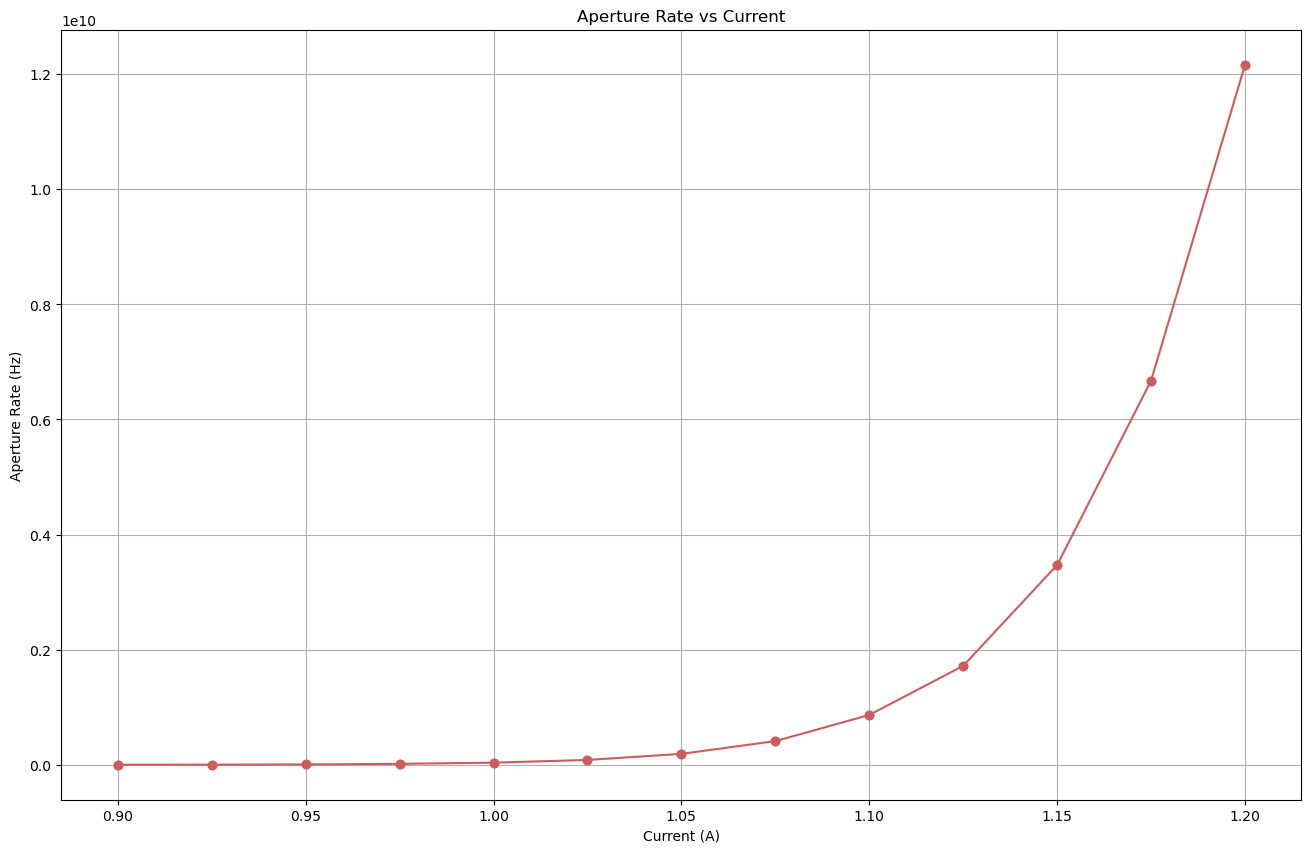

In [72]:
plt.figure(figsize = (16, 10))

# plt.subplot(1,2,1)
plt.plot(run2['amps'], run2['ap_rate'], marker='o', label='Aperture Current', color='indianred')
plt.errorbar(run2['amps'], run2['ap_rate'], yerr=run2['ap_rate_err'] * 1.602e-19 * 1e12, fmt='o', color='indianred', ecolor='indianred', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('Aperture Rate (Hz)')
plt.title('Aperture Rate vs Current')
plt.grid()

# plt.subplot(1,2,2)
# plt.plot(run2['amps'], run2['ap_rate'], marker='o', label='Efficiency', color='steelblue')
# plt.errorbar(run2['amps'], run2['ap_rate'], yerr=run2['ap_rate_err'], fmt='o', color='steelblue', ecolor='steelblue', elinewidth=3, capsize=0)
# plt.xlabel('Current (A)')
# plt.ylabel('Aperture Rate (Hz)')
# plt.title('Aperture Rate vs Current')
# plt.grid()

plt.show()

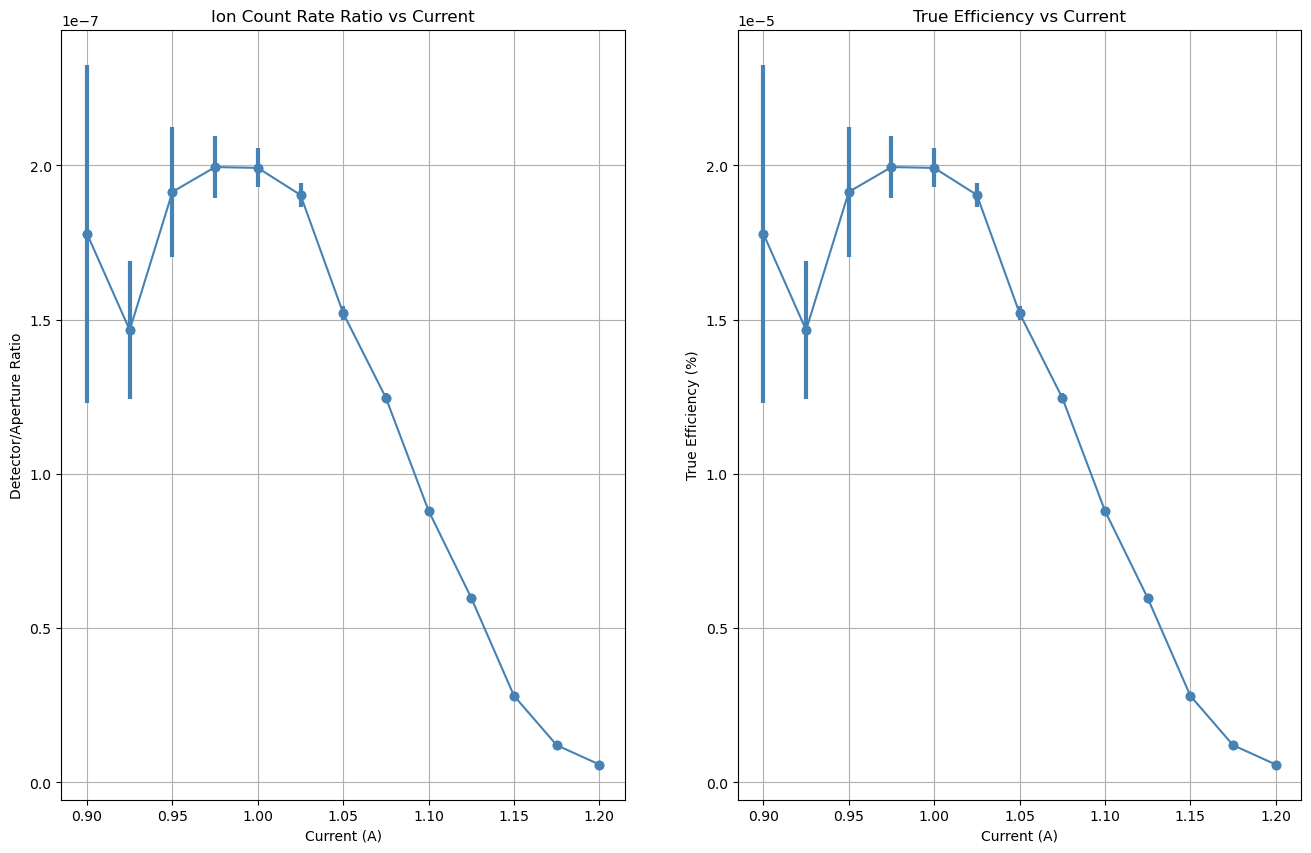

In [59]:
plt.figure(figsize=(16,10))
plt.subplot(1,2,1)
plt.plot(run2['amps'], run2['ratio'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(run2['amps'], run2['ratio'], yerr=run2['ratio'] * np.sqrt((run2['rate_err'] / run2['rate_hz'])**2 + (run2['ap_rate_err'] / run2['ap_rate'])**2), fmt='o', color='steelblue', ecolor='steelblue', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('Detector/Aperture Ratio')
plt.title('Ion Count Rate Ratio vs Current')
plt.grid()

plt.subplot(1,2,2)
plt.plot(run2['amps'], run2['efficiency'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(run2['amps'], run2['efficiency'], yerr=run2['efficiency'] * np.sqrt((run2['rate_err'] / run2['rate_hz'])**2 + (run2['ap_rate_err'] / run2['ap_rate'])**2), fmt='o', color='steelblue', ecolor='steelblue', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('True Efficiency (%)')
plt.title('True Efficiency vs Current')
plt.grid()

plt.show()
